## 1. Random Sample imputation:

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import MissingIndicator,SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('dataset/train.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [6]:
df.isnull().mean() * 100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [7]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [14]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [15]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [16]:
# For training set
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_train['Age'].dropna().sample(X_train['Age_imputed'].isnull().sum(), random_state=42).values
)

# For test set
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_train['Age'].dropna().sample(X_test['Age_imputed'].isnull().sum(), random_state=42).values
)


In [17]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([19.  , 32.  , 48.  , 22.  ,  3.  , 14.  , 22.  , 38.  , 23.  ,
       18.  , 50.  , 39.  , 25.  , 19.  , 47.  , 30.  , 17.  , 23.5 ,
        9.  , 44.  , 16.  ,  1.  , 41.  , 25.  , 19.  ,  0.83, 56.  ,
       21.  , 18.  , 22.  , 32.5 , 37.  , 37.  , 34.  , 50.  , 36.  ,
       28.  ,  0.75, 26.  , 36.  , 19.  ,  2.  , 47.  , 12.  , 18.  ,
       27.  , 11.  , 18.  , 40.  , 30.  , 21.  , 47.  , 18.  , 22.  ,
       18.  ,  4.  ,  2.  , 33.  , 42.  , 16.  , 40.  , 18.  , 56.  ,
       33.  , 16.  , 45.  , 16.  , 30.  , 27.  , 23.  , 24.  , 24.  ,
       33.  , 28.  , 27.  , 57.  , 33.  , 22.  ,  9.  , 40.  , 18.  ,
       29.  , 14.  , 64.  , 51.  , 36.  , 41.  , 15.  , 35.  , 50.  ,
        0.42, 48.  , 24.  , 24.  , 24.  , 22.  , 42.  , 19.  , 24.  ,
       60.  , 16.  , 34.  , 16.  ,  9.  , 28.  , 42.  , 14.  , 39.  ,
       25.  , 25.  , 35.  , 32.  , 21.  , 26.  , 30.  , 16.  , 40.  ,
       36.5 , 30.  , 23.  , 30.  , 26.  , 31.  , 54.  , 27.  , 30.  ,
       40.  ,  9.  ,

In [19]:
X_train['Age'].isnull().sum() # total null values, so above code gets as many random values as missing and replaces them

np.int64(148)

In [20]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,18.0
493,71.0,49.5042,71.0
527,NaN,221.7792,21.0


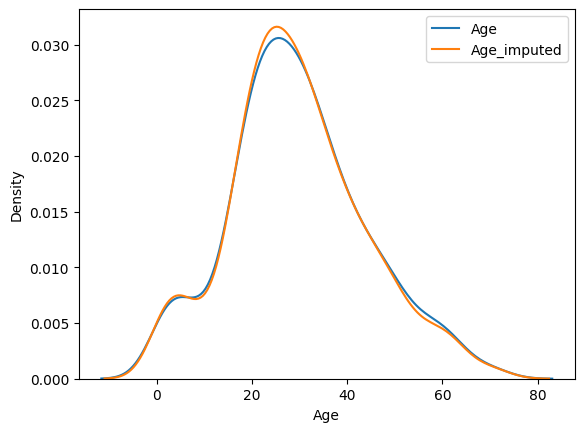

In [29]:
sns.kdeplot(data=X_train,x='Age',label='Age')
sns.kdeplot(data=X_train,x='Age_imputed',label='Age_imputed')
plt.legend()
plt.show()

In [30]:
print('Original variable variance: ', X_train['Age'].var())
print('Variance after random imputation: ', X_train['Age_imputed'].var())

Original variable variance:  204.34951339046142
Variance after random imputation:  200.02896637747122


#### Not much variance and distribution difference in random imputation

In [33]:
X_train[['Fare', 'Age', 'Age_imputed']].cov() # Covariance with other columns changes in Random imputation

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,53.259863
Age,71.512440,204.349513,204.349513
Age_imputed,53.259863,204.349513,200.028966


<Axes: >

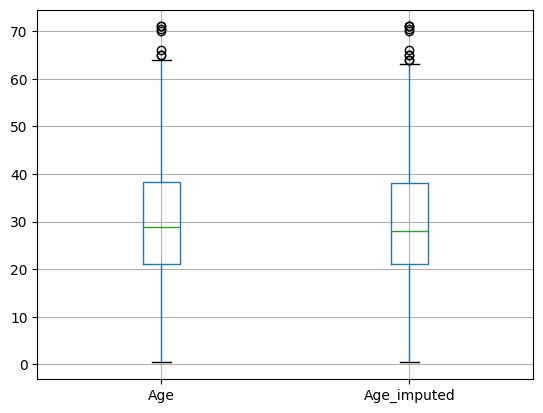

In [34]:
X_train[['Age', 'Age_imputed']].boxplot()

#### Note: When using this technique in production, if value is missing and this technique is used to place random value, if one variable is given like in this case `Fare` and `Age` is missing any random value of `Age` will be added to the model to predict and it will always give different predictions for the same value of `Fare` as other will be added random which is not good for any real life predictions, so we use this method that tracks which variable input is given and for that always same value of `Age` or any other column that is randomly imputing is added to the model or given.

In [42]:
observation = X_train.iloc[0]
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))
sampled_value     # How many times you run the code the stored 'Age' value will be same in 'sampled_value'

399    28.0
Name: Age, dtype: float64

### Different Dataset

In [44]:
data = pd.read_csv('dataset/house-train.csv',usecols=['GarageQual','FireplaceQu', 'SalePrice'])

In [45]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [46]:
data.isnull().mean() * 100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [47]:
X = data
y = data['SalePrice']

In [48]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [49]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [50]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
642,TA,TA,345000,TA,TA
904,NaN,TA,125500,TA,NaN
650,NaN,TA,205950,TA,NaN
1039,NaN,TA,80000,TA,NaN
127,TA,NaN,87000,NaN,TA


In [51]:
# GarageQual imputation
X_train.loc[X_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    X_train['GarageQual'].dropna()
    .sample(X_train['GarageQual_imputed'].isnull().sum(), replace=True, random_state=42)
    .values
)

X_test.loc[X_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = (
    X_train['GarageQual'].dropna()
    .sample(X_test['GarageQual_imputed'].isnull().sum(), replace=True, random_state=43)
    .values
)

# FireplaceQu imputation
X_train.loc[X_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu'].dropna()
    .sample(X_train['FireplaceQu_imputed'].isnull().sum(), replace=True, random_state=44)
    .values
)

X_test.loc[X_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = (
    X_train['FireplaceQu'].dropna()
    .sample(X_test['FireplaceQu_imputed'].isnull().sum(), replace=True, random_state=45)
    .values
)


In [52]:
temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [54]:
temp # Percentage of categories before and after imputation of the column 'GarageQual'

,original,imputed
TA,0.951043,0.950342
Fa,0.037171,0.036815
Gd,0.009973,0.011130
Po,0.000907,0.000856
Ex,0.000907,0.000856


#### Note: Not much change in the percentages so we can use random imputation for this column

In [55]:
temp = pd.concat(
        [
            X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
            X_train['FireplaceQu_imputed'].value_counts() / len(df)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

temp

,original,imputed
Gd,0.494272,0.630752
TA,0.412439,0.566779
Fa,0.040917,0.046016
Po,0.027823,0.035915
Ex,0.024550,0.031425


#### Note: Much change in the percentages so we cannot use random imputation for this column

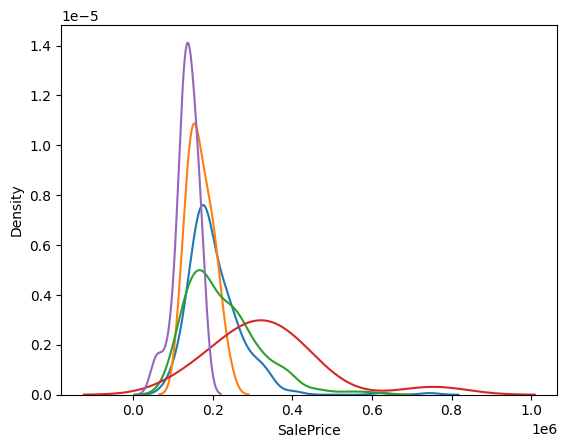

In [57]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.show()

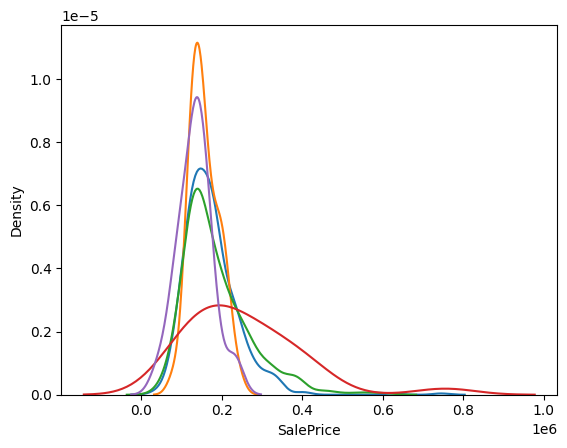

In [59]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)
plt.show()

#### Note: For this column, distribution also changes that's why we don't use this imputation for this column also random imputation works well on linear regression models and don't perform well on decision trees due to randomness.

## 2. Missing Indicator imputation

In [62]:
df = pd.read_csv('dataset/train.csv',usecols=['Age','Fare','Survived'])

In [63]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [64]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [66]:
X_train.head()

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458


### 1. Without Imputation

In [67]:
si = SimpleImputer()
X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

In [68]:
X_train_trf

array([[ 40.        ,  27.7208    ],
       [  4.        ,  16.7       ],
       [ 47.        ,   9.        ],
       ...,
       [ 71.        ,  49.5042    ],
       [ 29.78590426, 221.7792    ],
       [ 29.78590426,  25.925     ]])

In [69]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X_train_trf,y_train)

y_pred = clf.predict(X_test_trf)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6145251396648045

### 2. With MisingIndicator class

In [70]:
mi = MissingIndicator()

mi.fit(X_train)

,missing_values,nan
,features,'missing-only'
,sparse,'auto'
,error_on_new,True


In [71]:
mi.features_

array([0])

In [72]:
X_train_missing = mi.transform(X_train)

In [ ]:
X_train_missing

In [74]:
X_test_missing = mi.transform(X_test)

In [ ]:
X_test_missing

In [76]:
X_train['Age_NA'] = X_train_missing

In [77]:
X_test

,Age,Fare
707,42.0,26.2875
37,21.0,8.0500
615,24.0,65.0000
169,28.0,56.4958
68,17.0,7.9250
...,...,...
89,24.0,8.0500
80,22.0,9.0000
846,NaN,69.5500
870,26.0,7.8958


In [78]:
X_test['Age_NA'] = X_test_missing

In [79]:
X_train

,Age,Fare,Age_NA
30,40.0,27.7208,False
10,4.0,16.7000,False
873,47.0,9.0000,False
182,9.0,31.3875,False
876,20.0,9.8458,False
...,...,...,...
534,30.0,8.6625,False
584,NaN,8.7125,True
493,71.0,49.5042,False
527,NaN,221.7792,True


In [82]:
si = SimpleImputer()  # filling missing values as Logistic Regression does not support missing values 

X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)

In [83]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X_train_trf2,y_train)

y_pred = clf.predict(X_test_trf2)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6312849162011173

### 3. Using Simple Imputer class of sklearn (Better Method)

In [84]:
si = SimpleImputer(add_indicator=True)

In [85]:
X_train = si.fit_transform(X_train)

In [86]:
X_test = si.transform(X_test)

In [87]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()

clf.fit(X_train_trf2,y_train)

y_pred = clf.predict(X_test_trf2)

from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.6312849162011173

## 3. Automatically Select Imputer and parameters

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [91]:
df = pd.read_csv('dataset/train.csv')

In [92]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [93]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [94]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [95]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [96]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [97]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
30,1,male,40.0,0,0,27.7208,C
10,3,female,4.0,1,1,16.7000,S
873,3,male,47.0,0,0,9.0000,S
182,3,male,9.0,4,2,31.3875,S
876,3,male,20.0,0,0,9.8458,S


In [98]:
numerical_features = ['Age', 'Fare']
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_features = ['Embarked', 'Sex']
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',OneHotEncoder(handle_unknown='ignore'))
])

In [99]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [100]:
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [101]:
from sklearn import set_config

set_config(display='diagram')
clf

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [102]:
param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'preprocessor__cat__imputer__strategy': ['most_frequent', 'constant'],
    'classifier__C': [0.1, 1.0, 10, 100]
}

grid_search = GridSearchCV(clf, param_grid, cv=10)

In [103]:
grid_search.fit(X_train, y_train)

print(f"Best params:")
print(grid_search.best_params_)

Best params:
{'classifier__C': 1.0, 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean'}


In [104]:
print(f"Internal CV score: {grid_search.best_score_:.3f}")

Internal CV score: 0.788


In [105]:
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values("mean_test_score", ascending=False)
cv_results[['param_classifier__C','param_preprocessor__cat__imputer__strategy','param_preprocessor__num__imputer__strategy','mean_test_score']]

,param_classifier__C,param_preprocessor__cat__imputer__strategy,param_preprocessor__num__imputer__strategy,mean_test_score
7,1.0,constant,median,0.787852
6,1.0,constant,mean,0.787852
5,1.0,most_frequent,median,0.787852
4,1.0,most_frequent,mean,0.787852
11,10.0,constant,median,0.787852
10,10.0,constant,mean,0.787852
9,10.0,most_frequent,median,0.787852
8,10.0,most_frequent,mean,0.787852
12,100.0,most_frequent,mean,0.787852
13,100.0,most_frequent,median,0.787852


## 2. KNN Inputation:

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.impute import KNNImputer,SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv('dataset/train.csv')[['Age','Pclass','Fare','Survived']]

In [4]:
df.head()

,Age,Pclass,Fare,Survived
0,22.0,3,7.2500,0
1,38.0,1,71.2833,1
2,26.0,3,7.9250,1
3,35.0,1,53.1000,1
4,35.0,3,8.0500,0


In [5]:
df.isnull().mean() * 100

Age         19.86532
Pclass       0.00000
Fare         0.00000
Survived     0.00000
dtype: float64

In [6]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [8]:
X_train.head()

,Age,Pclass,Fare
30,40.0,1,27.7208
10,4.0,3,16.7000
873,47.0,3,9.0000
182,9.0,3,31.3875
876,20.0,3,9.8458


#### Note: You should experiment with different `n_neighbors` and `weights` parameter

In [32]:
knn = KNNImputer(n_neighbors=2,weights='distance')
'''weights parameter tells us: 
'uniform' : uniform weights. All points in each neighborhood are weighted equally.
'distance' : weight points by the inverse of their distance. in this case, 
closer neighbors of a query point will have a greater influence than neighbors which are further away.
Default value is 'uniform'
'''
X_train_trf = knn.fit_transform(X_train)
X_test_trf = knn.transform(X_test)

In [33]:
lr = LogisticRegression()

lr.fit(X_train_trf,y_train)

y_pred = lr.predict(X_test_trf)

accuracy_score(y_test,y_pred)

0.7094972067039106

In [34]:
# Comparision with Simple Imputer --> mean

si = SimpleImputer()

X_train_trf2 = si.fit_transform(X_train)
X_test_trf2 = si.transform(X_test)

In [35]:
lr = LogisticRegression()

lr.fit(X_train_trf2,y_train)

y_pred2 = lr.predict(X_test_trf2)

accuracy_score(y_test,y_pred2)

0.6927374301675978

## 3. Multivariate Imputation by Chained Equations

### **Types of Missing Data**

Before deciding how to handle missing values, it’s important to understand their type:

1. **MCAR (Missing Completely At Random)**  
   The probability of missingness is unrelated to any variable in the dataset.  
   Example: Sensor randomly fails to record a value.

2. **MAR (Missing At Random)**  
   The probability of missingness is related to observed variables but not the missing variable itself.  
   Example: Older patients are less likely to answer income-related questions, but within each age group, missingness is random.

3. **MNAR (Missing Not At Random)**  
   The probability of missingness is related to the unobserved value itself.  
   Example: People with very high incomes are more likely to refuse disclosing their income.


#### Note: MICE works best on `MAR` dataset since, each column is much related to other columns

In [1]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [5]:
df=pd.read_csv('dataset/train.csv',usecols=['Sex','Age','Survived','Fare'])

In [6]:
df

,Survived,Sex,Age,Fare
0,0,male,22.0,7.2500
1,1,female,38.0,71.2833
2,1,female,26.0,7.9250
3,1,female,35.0,53.1000
4,0,male,35.0,8.0500
...,...,...,...,...
886,0,male,27.0,13.0000
887,1,female,19.0,30.0000
888,0,female,NaN,23.4500
889,1,male,26.0,30.0000


In [34]:
df.isnull().mean()*100

Survived     0.00000
Sex          0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[['Sex','Age','Fare']],df['Survived'],test_size=0.2)
X_train.shape, X_test.shape

((712, 3), (179, 3))

In [36]:
# Using label Encoding for 'Sex' since it has only two columns, we can also use OHE.
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X_train['Sex'] = le.fit_transform(X_train['Sex'])
X_test['Sex'] = le.transform(X_test['Sex'])

In [37]:
le.classes_

array(['female', 'male'], dtype=object)

In [38]:
X_train

,Sex,Age,Fare
597,1,49.0,0.0000
804,1,27.0,6.9750
859,1,NaN,7.2292
662,1,47.0,25.5875
657,0,32.0,15.5000
...,...,...,...
135,1,23.0,15.0458
857,1,51.0,26.5500
838,1,32.0,56.4958
238,1,19.0,10.5000


In [25]:
# MICE imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
imputer = IterativeImputer(max_iter=10,random_state=0)
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed= imputer.transform(X_test)

In [26]:
X_train_imputed

array([[ 0.        , 22.        , 29.        ],
       [ 0.        , 27.32788804, 15.5       ],
       [ 0.        , 21.        , 34.375     ],
       ...,
       [ 0.        , 17.        ,  7.925     ],
       [ 1.        , 45.5       ,  7.225     ],
       [ 0.        , 39.        , 31.275     ]])

In [31]:
X_train_m = pd.DataFrame(X_train_imputed, columns=X_train.columns, index=X_train.index)
X_test_m = pd.DataFrame(X_test_imputed, columns=X_test.columns, index=X_test.index)

In [43]:
y_train_m=y_train
y_test_m=y_test

In [32]:
X_train_m

,Sex,Age,Fare
323,0.0,22.000000,29.000
241,0.0,27.327888,15.500
436,0.0,21.000000,34.375
419,0.0,10.000000,24.150
147,0.0,9.000000,34.375
...,...,...,...
498,0.0,25.000000,151.550
383,0.0,35.000000,52.000
68,0.0,17.000000,7.925
203,1.0,45.500000,7.225


In [33]:
X_train_m.isnull().mean()

Sex     0.0
Age     0.0
Fare    0.0
dtype: float64

In [39]:
X_train['Age']

,Sex,Age,Fare
597,1,49.0,0.0000
804,1,27.0,6.9750
859,1,NaN,7.2292
662,1,47.0,25.5875
657,0,32.0,15.5000
...,...,...,...
135,1,23.0,15.0458
857,1,51.0,26.5500
838,1,32.0,56.4958
238,1,19.0,10.5000


#### Using Mean to impute Age also

In [40]:
from sklearn.impute import SimpleImputer

# Create imputer with mean strategy
mean_imputer = SimpleImputer(strategy="mean")

# Fit on train, transform both
X_train['Age'] = mean_imputer.fit_transform(X_train[['Age']])  # keep 2D with [[]]
X_test['Age'] = mean_imputer.transform(X_test[['Age']])

In [42]:
X_train.isnull().mean()

Sex     0.0
Age     0.0
Fare    0.0
dtype: float64

#### Finding Accuracy for both imputations

In [49]:
# for Mean imputation first
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=0)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

Accuracy: 0.7653631284916201


In [50]:
# Train logistic regression
model = LogisticRegression(max_iter=1000, random_state=0)
model.fit(X_train_m, y_train_m)

# Predictions
y_pred = model.predict(X_test_m)

# Accuracy
acc = accuracy_score(y_test_m, y_pred)
print("Accuracy:", acc)

Accuracy: 0.6145251396648045


#### Note: MICE didn't performed well as compared to Mean imputation because the dataset was small and it couldn't predict well also MICE is experimental in scikit learn. For titanic dataset, categorizing the `Age` was proved most efficient and we will try that in future.